# VaR and GARCH

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

The stock obeys an underlying geometric motion

$$ S_{t+1} = S_{t} \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}X  \right)$$

## Create Synthetic Data

In [3]:
#number of days
T = 2000

#drift 
mu = 0.0004

#volatility 
sigma_t = np.full(T, 0.008)      # calm baseline
sigma_t[600:900]  = 0.030        # crisis
sigma_t[1400:1600] = 0.022       # aftershock


In [4]:
S0 = 1. #price of stock at T=1.

#standard normal distribution sampled T times
X = np.random.normal(loc=0.,
    scale=1.,
    size=T) #we do not use the last one.


#creating synthetic stock data
S = np.zeros(T)
S[0] = S0
for i in range(1, T):
    S[i] = S[i-1]*np.exp((mu - sigma_t[i-1]**2/2) + sigma_t[i-1]*X[i-1])
    


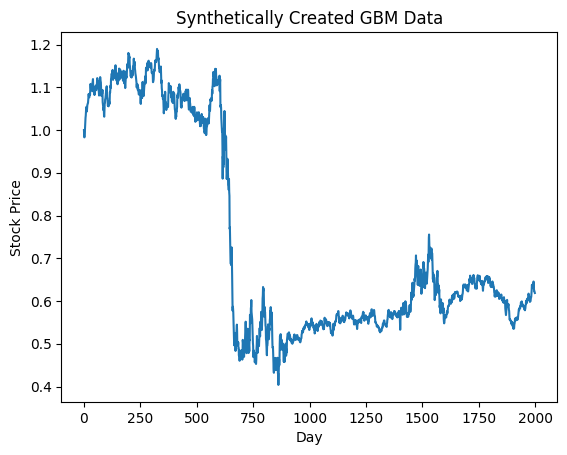

In [5]:
plt.plot(S)
plt.xlabel('Day')
plt.ylabel('Stock Price')
plt.title('Synthetically Created GBM Data')
plt.show()

## Calculate Log Returns

$$ r_t = \log\frac{S_t}{S_{t-1}} = \log S_t - \log S_{t-1} = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}X_{t-1} $$

Therefore returns follow a Gaussian $N\left(\left(\mu - \frac{\sigma^2}{2} \right)\Delta t , \sigma^2 \Delta t \right)$

In [6]:
#use log returns here

returns = np.diff(np.log(S))          # length T-1

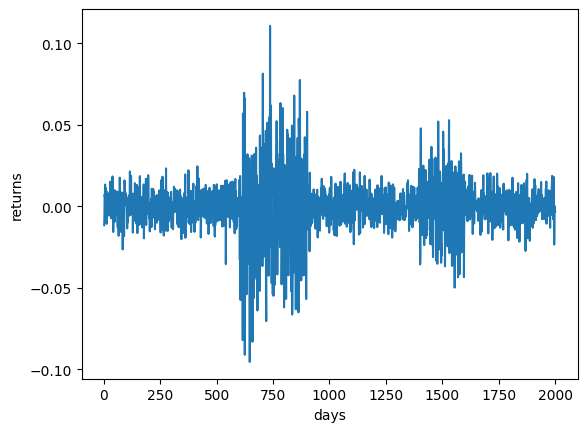

In [7]:
plt.plot(np.arange(2,T+1), returns)
plt.ylabel('returns')
plt.xlabel('days')
plt.show()

In [8]:
#returns_mean_ana = (mu - sigma**2/2.)*1.

#returns_sigma_ana = sigma*np.sqrt(1.)

returns_mean_syn, returns_sigma_syn = returns.mean(), returns.std(ddof=1)

#print(returns_mean_ana)
print(returns_mean_syn)
#print(returns_sigma_ana)
print(returns_sigma_syn)

-0.000240119178840095
0.015658349746513273


When sigma is constant, The analytical value and synthetic values agree well. The plot below makes this agreement visual too.

In [9]:
# VaR_ana = scipy.stats.norm.ppf(0.01, returns_mean_ana, returns_sigma_ana)

VaR_ana = scipy.stats.norm.ppf(0.01, returns_mean_syn, returns_sigma_syn)

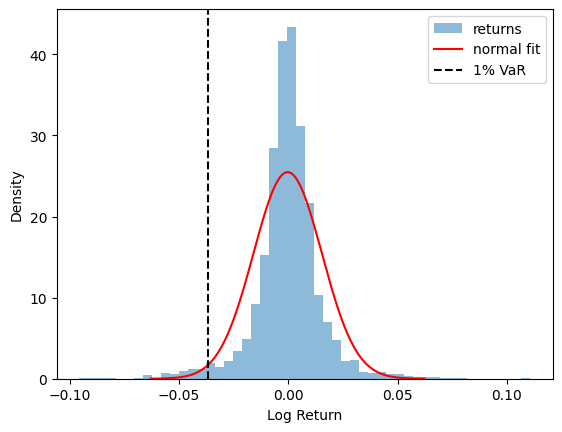

In [10]:

x_plot = np.linspace(returns_mean_syn- 4*returns_sigma_syn, returns_mean_syn+ 4*returns_sigma_syn, 400)

plt.hist(returns, bins=50, density=True, alpha=0.5, label='returns')
#plt.plot(x_plot, scipy.stats.norm.pdf(x_plot, returns_mean_ana, returns_sigma_ana), 'r', label='normal fit')
plt.plot(x_plot, scipy.stats.norm.pdf(x_plot, returns_mean_syn, returns_sigma_syn), 'r', label='normal fit')
plt.axvline(VaR_ana, c='k', ls='--', label='1% VaR')
plt.xlabel('Log Return'); plt.ylabel('Density'); plt.legend()
plt.show()

## VaR and Conditional VaR

To avoid headaches, define VaR as a quantile and conditional VaR as the expectation in the region from $(-\infty, VaR)$

In [11]:
sorted_returns = np.sort(returns)

VaR_syn = sorted_returns[int(len(sorted_returns)*0.01)] #little loose but works

In [12]:
print(VaR_syn) 
print(VaR_ana)

-0.05233279782683298
-0.03666688782262918


When sigma is constant, The expected number of breaches give a VaR that is close to that of the underlying distribution.

When sigma is variable, the tail is fatter and VaR is more negative

In [13]:
conditional_VaR = sorted_returns[0:int(len(sorted_returns)*0.01)+1].mean()

In [14]:
print(conditional_VaR)

-0.06474642541271554


## EWMA and GARCH

In [15]:
from scipy.optimize import minimize

In [16]:
returns_mean_zero = returns - returns.mean()          # both model the mean-zero residual. The variance of X-mu = variance of X with mean mu 


$$ \sigma_t^2 = \lambda \sigma_{t-1}^2 + (1 - \lambda)r_{t-1}^2$$

In [17]:
#EWMA = exponentially-weighted moving average

def ewma_sigma(e, lam=0.94):
    s2 = np.empty(len(e)); s2[0] = e.var() #this is a hack to seed EWMA
    for t in range(1, len(e)):
        s2[t] = lam*s2[t-1] + (1-lam)*e[t-1]**2
    return np.sqrt(s2)

In [18]:
sig_ewma = ewma_sigma(returns_mean_zero)

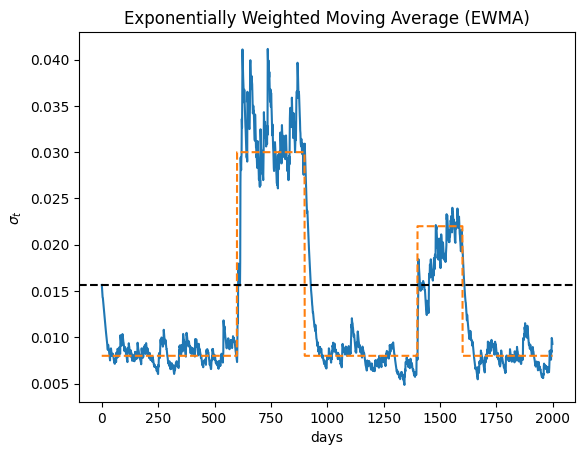

In [19]:
plt.plot(sig_ewma)
plt.plot(sigma_t, linestyle='dashed')
plt.xlabel('days')
plt.ylabel(r'$\sigma_t$')
plt.axhline(y = returns_sigma_syn, c='black', linestyle='dashed')
plt.title('Exponentially Weighted Moving Average (EWMA)')
plt.show()

$$ \sigma_t^2 = \omega + \alpha r^2_{t-1} + \beta \sigma^2_{t-1}$$

$$ \mathbb{E}[\sigma^2] = \frac{\omega}{1 - \alpha - \beta}$$

In [20]:




def garch_fit(e):
    s = 100.0; x = e*s                # rescale zero mean returns to make optimization easier

    def recurse(w, a, b): #this is what we want optimized
        s2 = np.empty(len(x)); s2[0] = x.var()
        for t in range(1, len(x)):
            s2[t] = w + a*x[t-1]**2 + b*s2[t-1]
        return s2
    
    def nll(p):
        w, a, b = p
        if w <= 0 or a < 0 or b < 0 or a + b >= 0.9999:
            return 1e10 #fail-safe
        s2 = recurse(w, a, b)
        return 0.5*np.sum(np.log(2*np.pi*s2) + x**2/s2) #negative log-likelihood under a Gaussian probability density
    
    v = x.var() #use initial guess as the long time result
    res = minimize(nll, [v*0.05, 0.05, 0.90], method='Nelder-Mead',
                   options={'maxiter': 5000, 'xatol': 1e-10, 'fatol': 1e-10})
    
    w, a, b = res.x
    return (w/s**2, a, b), np.sqrt(recurse(w, a, b))/s #rescale by s factor wherever necessary


(w, a, b), sig_garch = garch_fit(returns_mean_zero)

print(f'omega={w:.3e}  alpha={a:.4f}  beta={b:.4f}  alpha+beta={a+b:.4f}')
print('long-run sigma =', np.sqrt(w/(1-a-b)), ' synthetic value =', returns_sigma_syn)

omega=1.684e-06  alpha=0.0875  beta=0.9022  alpha+beta=0.9897
long-run sigma = 0.012766639308864753  synthetic value = 0.015658349746513273


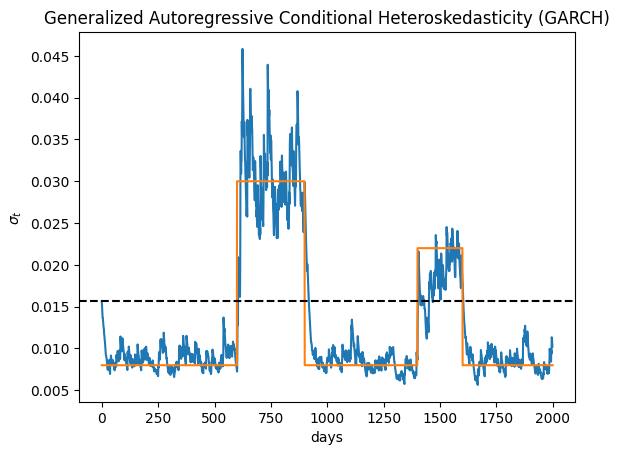

In [21]:
plt.plot(sig_garch)
plt.plot(sigma_t)
plt.xlabel('days')
plt.ylabel(r'$\sigma_t$')
plt.axhline(y = returns_sigma_syn, c='black', linestyle='dashed')
plt.title('Generalized Autoregressive Conditional Heteroskedasticity (GARCH)')
plt.show()

## VaR BREACH COUNT

In [22]:
(returns < VaR_ana).sum()

51

In [23]:
static_VaR_violation_indices = np.where(returns < VaR_ana)[0]

In [25]:
static_VaR_violation_indices

array([ 604,  613,  614,  623,  631,  645,  647,  649,  655,  656,  657,
        658,  662,  663,  665,  670,  671,  679,  689,  717,  718,  726,
        729,  742,  747,  750,  756,  767,  786,  797,  798,  803,  806,
        816,  828,  830,  833,  834,  835,  840,  849,  858,  861,  873,
        884,  895, 1510, 1553, 1568, 1576, 1594], dtype=int64)

This will be 20-ish when sigma is constant. When sigma is variable, VaR breaches happen more frequently

In [26]:

garch_VaR_violation_indices = []
for i in range(0, len(returns)):
    if returns[i]< scipy.stats.norm.ppf(0.01, mu - sig_garch[i]**2./2., sig_garch[i]):
        garch_VaR_violation_indices.append(i)

In [27]:
len( garch_VaR_violation_indices)

25

In [28]:
garch_VaR_violation_indices = np.array(garch_VaR_violation_indices)

In [29]:
garch_VaR_violation_indices

array([  64,   82,  176,  250,  342,  428,  539,  601,  604,  613,  614,
        645,  657,  895, 1400, 1553, 1568, 1594, 1667, 1720, 1791, 1830,
       1840, 1867, 1994])

This will always be 20-ish. GARCH follows the volatility drift and so the VaR breach is more sensible

## Visualize

In [85]:
def plot_frame(index, ax0, ax1, ax2):
    #gaussian plot ##############################################################################
    garch_mean = mu - sig_garch[index]**2./2.
    
    x_plot_garch = np.linspace(garch_mean- 4*sig_garch[index], garch_mean+ 4*sig_garch[index], 400)
    x_plot_static = np.linspace(returns_mean_syn- 4*returns_sigma_syn, returns_mean_syn+ 4*returns_sigma_syn, 400)

    ax0.hist(returns, bins=50, density=True, alpha=0.5)

    ax0.plot(x_plot, scipy.stats.norm.pdf(x_plot_static, returns_mean_syn, returns_sigma_syn), 'r', label='Static fit')

    ax0.plot(x_plot, scipy.stats.norm.pdf(x_plot_garch,garch_mean, sig_garch[index] ), 'green', label='GARCH fit')

    VaR_GARCH = scipy.stats.norm.ppf(0.01, garch_mean, sig_garch[index])
    ax0.axvline(VaR_ana, c='black', ls='--', label='Static 1% VaR')
    ax0.axvline(VaR_GARCH, c='gray', ls='--', label='GARCH 1% VaR')
    ax0.set_xlabel('Log Return', fontsize=20)
    ax0.set_ylabel('Density of Log Return', fontsize=20)
    ax0.legend(fontsize=12)
    ax0.set_xlim([-0.125,0.125])
    ax0.set_ylim([0, 60])

    #static vol plot ############################################################################

    ax1.scatter(np.arange(2,T+1)[0:index+1], returns[0:index+1], s=5)
    
    static_breach_running_count = (static_VaR_violation_indices <= index).sum()
    ax1.annotate('VaR Breach: '+str(static_breach_running_count), (1200,-0.095), fontsize=15 , c='red')
    ax1.axhline(y = VaR_ana, c='black', linestyle='dashed')
    ax1.set_ylabel('Log Return', fontsize=15)
    ax1.set_xlabel('Days', fontsize=15)
    ax1.set_xlim([-30,2030])
    ax1.set_ylim([-0.125,0.125])
    
    #garch vol plot#######################################################################

    ax2.scatter(np.arange(2,T+1)[0:index+1], returns[0:index+1], s=5)
    garch_breach_running_count = (garch_VaR_violation_indices <= index).sum()
    ax2.annotate('VaR Breach: '+str(garch_breach_running_count), (1200,-0.095), fontsize=15 , c='green')

    ax2.set_xlim([-30,2030])
    ax2.set_ylim([-0.125,0.125])
    ax2.axhline(y = VaR_GARCH, c='gray', linestyle='dashed')
    ax2.set_ylabel('Log Return', fontsize=15)
    ax2.set_xlabel('Days', fontsize=15)
    

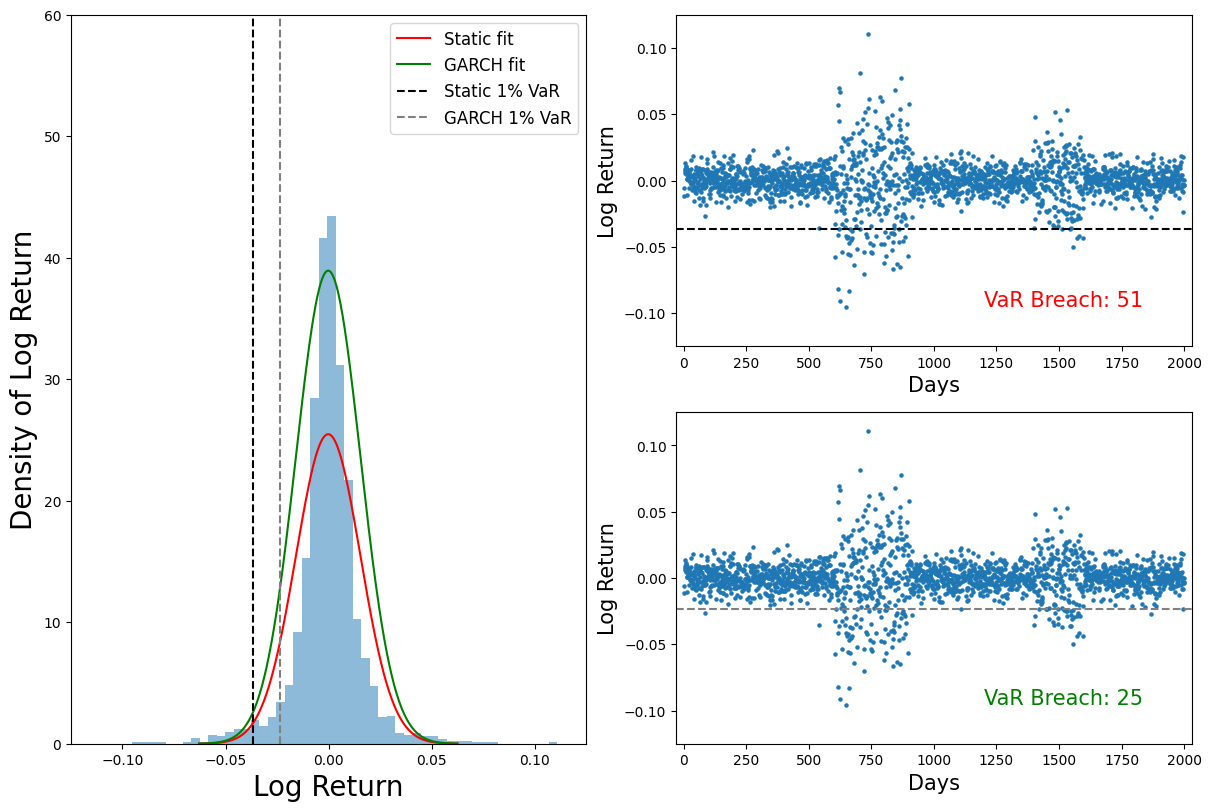

In [86]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs  = fig.add_gridspec(2, 2)
gaussians = fig.add_subplot(gs[:, 0])     # col 1, both rows
returns_static_vol = fig.add_subplot(gs[0, 1])     # row 0, col 1
returns_garch_vol = fig.add_subplot(gs[1, 1])     # row 1, col 1

#fig.suptitle('Time: '+str("%.3f" %(pendus[0].t[1000])), c='white', fontsize =20)
#fig.patch.set_facecolor('black')
#top.set_facecolor('black')
#p_q.set_facecolor('black')
#P_Q.set_facecolor('black')
plot_frame(1998, gaussians, returns_static_vol, returns_garch_vol)
plt.show()

## Movie

In [77]:
from matplotlib.animation import PillowWriter

In [78]:
metadata = dict(title='Movie', artist ='ayush_roy')
writer = PillowWriter(fps=10, metadata = metadata)

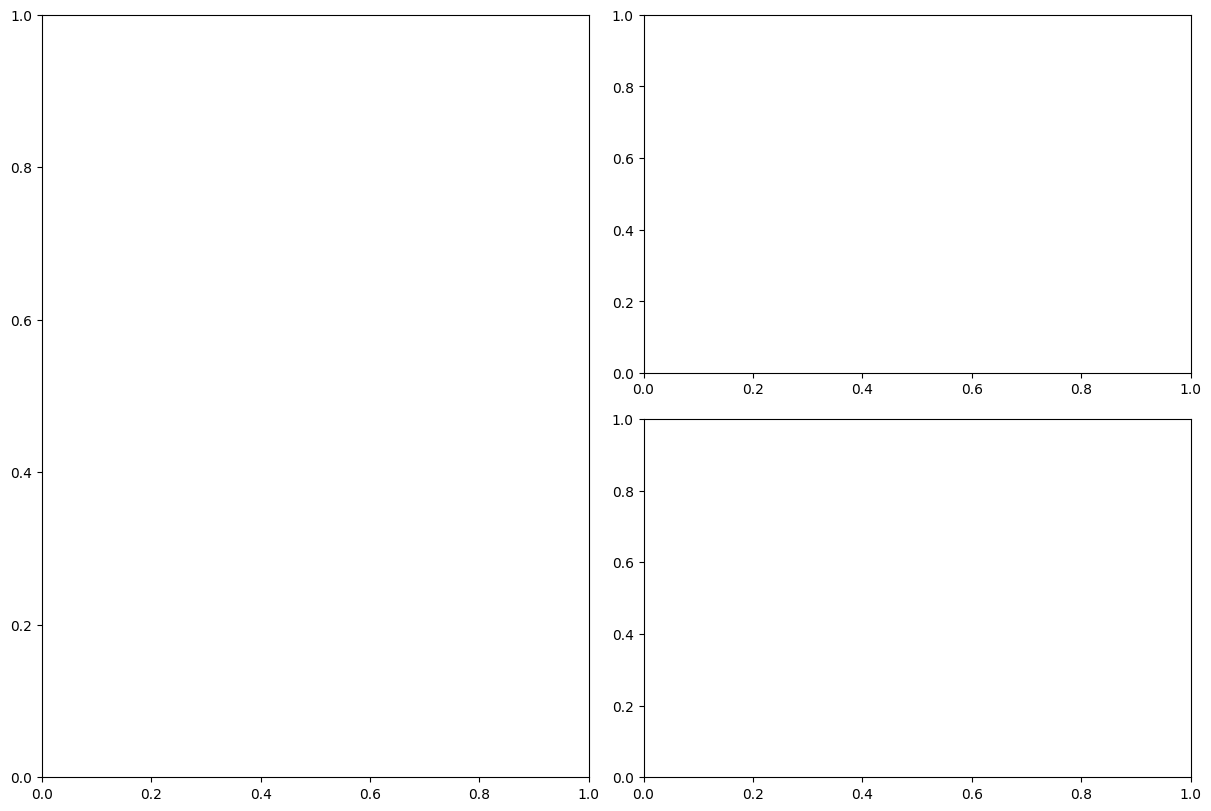

In [87]:

fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs  = fig.add_gridspec(2, 2)
gaussians = fig.add_subplot(gs[:, 0])     # col 1, both rows
returns_static_vol = fig.add_subplot(gs[0, 1])     # row 0, col 1
returns_garch_vol = fig.add_subplot(gs[1, 1])     # row 1, col 1

with writer.saving(fig, 'VaR_GARCH.gif',100):
    for i in range(0, len(returns)):
        if i%8 == 0 or i==len(returns)-1:
          
            plot_frame(i,gaussians, returns_static_vol, returns_garch_vol )
            writer.grab_frame()
            gaussians.clear()
            returns_static_vol.clear()
            returns_garch_vol.clear()